# ❤️ Heart Failure Prediction

This notebook builds a supervised machine learning pipeline to predict the likelihood of death due to heart failure using real-world clinical data. Three classifiers are trained and evaluated head-to-head: **SVM**, **K-Nearest Neighbors**, and **Logistic Regression**.

### Pipeline Overview
1. Import libraries
2. Load and explore the dataset
3. Visualize key patterns and distributions
4. Preprocess and standardize features
5. Train/test split
6. Train and evaluate three models
7. Compare model performance visually

## 1. Import Libraries

We import everything needed for data processing, visualization, modeling, and evaluation.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

## 2. Load & Explore the Dataset

The dataset contains **299 patient records** collected during follow-up periods at a medical centre. Each row represents one patient with 12 clinical features and a binary outcome:
- `0` → Survived
- `1` → Deceased

In [16]:
# Load the dataset
df = pd.read_csv('heart_failure_clinical_records_dataset.csv')

print(f'Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head(10)

Dataset shape: 299 rows × 13 columns


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
5,90.0,1,47,0,40,1,204000.00,2.1,132,1,1,8,1
6,75.0,1,246,0,15,0,127000.00,1.2,137,1,0,10,1
7,60.0,1,315,1,60,0,454000.00,1.1,131,1,1,10,1
8,65.0,0,157,0,65,0,263358.03,1.5,138,0,0,10,1
9,80.0,1,123,0,35,1,388000.00,9.4,133,1,1,10,1


In [17]:
# Data types, non-null counts, and missing value check
print('=== Dataset Info ===')
df.info()

print('\n=== Missing Values ===')
print(df.isnull().sum())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 

In [18]:
# Summary statistics — transposed for readability
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])

,count,mean,std,min,25%,50%,75%,max
age,299.000000,60.833893,11.894809,40.000000,51.000000,60.000000,70.000000,95.000000
anaemia,299.000000,0.431438,0.496107,0.000000,0.000000,0.000000,1.000000,1.000000
creatinine_phosphokinase,299.000000,581.839465,970.287881,23.000000,116.500000,250.000000,582.000000,7861.000000
diabetes,299.000000,0.418060,0.494067,0.000000,0.000000,0.000000,1.000000,1.000000
ejection_fraction,299.000000,38.083612,11.834841,14.000000,30.000000,38.000000,45.000000,80.000000
high_blood_pressure,299.000000,0.351171,0.478136,0.000000,0.000000,0.000000,1.000000,1.000000
platelets,299.000000,263358.029264,97804.236869,25100.000000,212500.000000,262000.000000,303500.000000,850000.000000
serum_creatinine,299.000000,1.393880,1.034510,0.500000,0.900000,1.100000,1.400000,9.400000
serum_sodium,299.000000,136.625418,4.412477,113.000000,134.000000,137.000000,140.000000,148.000000
sex,299.000000,0.648829,0.478136,0.000000,0.000000,1.000000,1.000000,1.000000


In [19]:
# Class distribution
class_counts = df['DEATH_EVENT'].value_counts()
print('Class Distribution:')
print(f'  Survived  (0): {class_counts[0]} patients ({class_counts[0]/len(df)*100:.1f}%)')
print(f'  Deceased  (1): {class_counts[1]} patients ({class_counts[1]/len(df)*100:.1f}%)')

Class Distribution:
  Survived  (0): 203 patients (67.9%)
  Deceased  (1): 96 patients (32.1%)


In [20]:
# Mean feature values grouped by outcome
print('Average feature values by survival status:')
df.groupby('DEATH_EVENT').mean().T.style.background_gradient(cmap='RdYlGn', axis=1)

Average feature values by survival status:


DEATH_EVENT,0,1
age,58.761906,65.215281
anaemia,0.408867,0.479167
creatinine_phosphokinase,540.054187,670.197917
diabetes,0.418719,0.416667
ejection_fraction,40.266010,33.468750
high_blood_pressure,0.325123,0.406250
platelets,266657.489901,256381.044792
serum_creatinine,1.184877,1.835833
serum_sodium,137.216749,135.375000
sex,0.650246,0.645833


## 3. Data Visualization

Before modeling, we explore the data visually to understand distributions, class balance, feature relationships, and potential outliers.

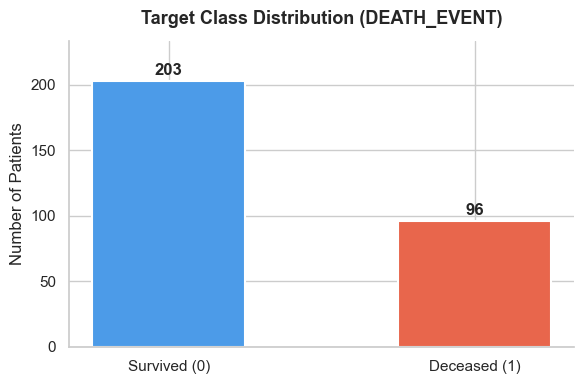

In [21]:
# Class distribution bar chart
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Survived (0)', 'Deceased (1)'], class_counts.values,
               color=['#4C9BE8', '#E8664C'], edgecolor='white', linewidth=1.5, width=0.5)

for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(count), ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_title('Target Class Distribution (DEATH_EVENT)', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Number of Patients')
ax.set_ylim(0, max(class_counts.values) * 1.15)
sns.despine()
plt.tight_layout()
plt.show()

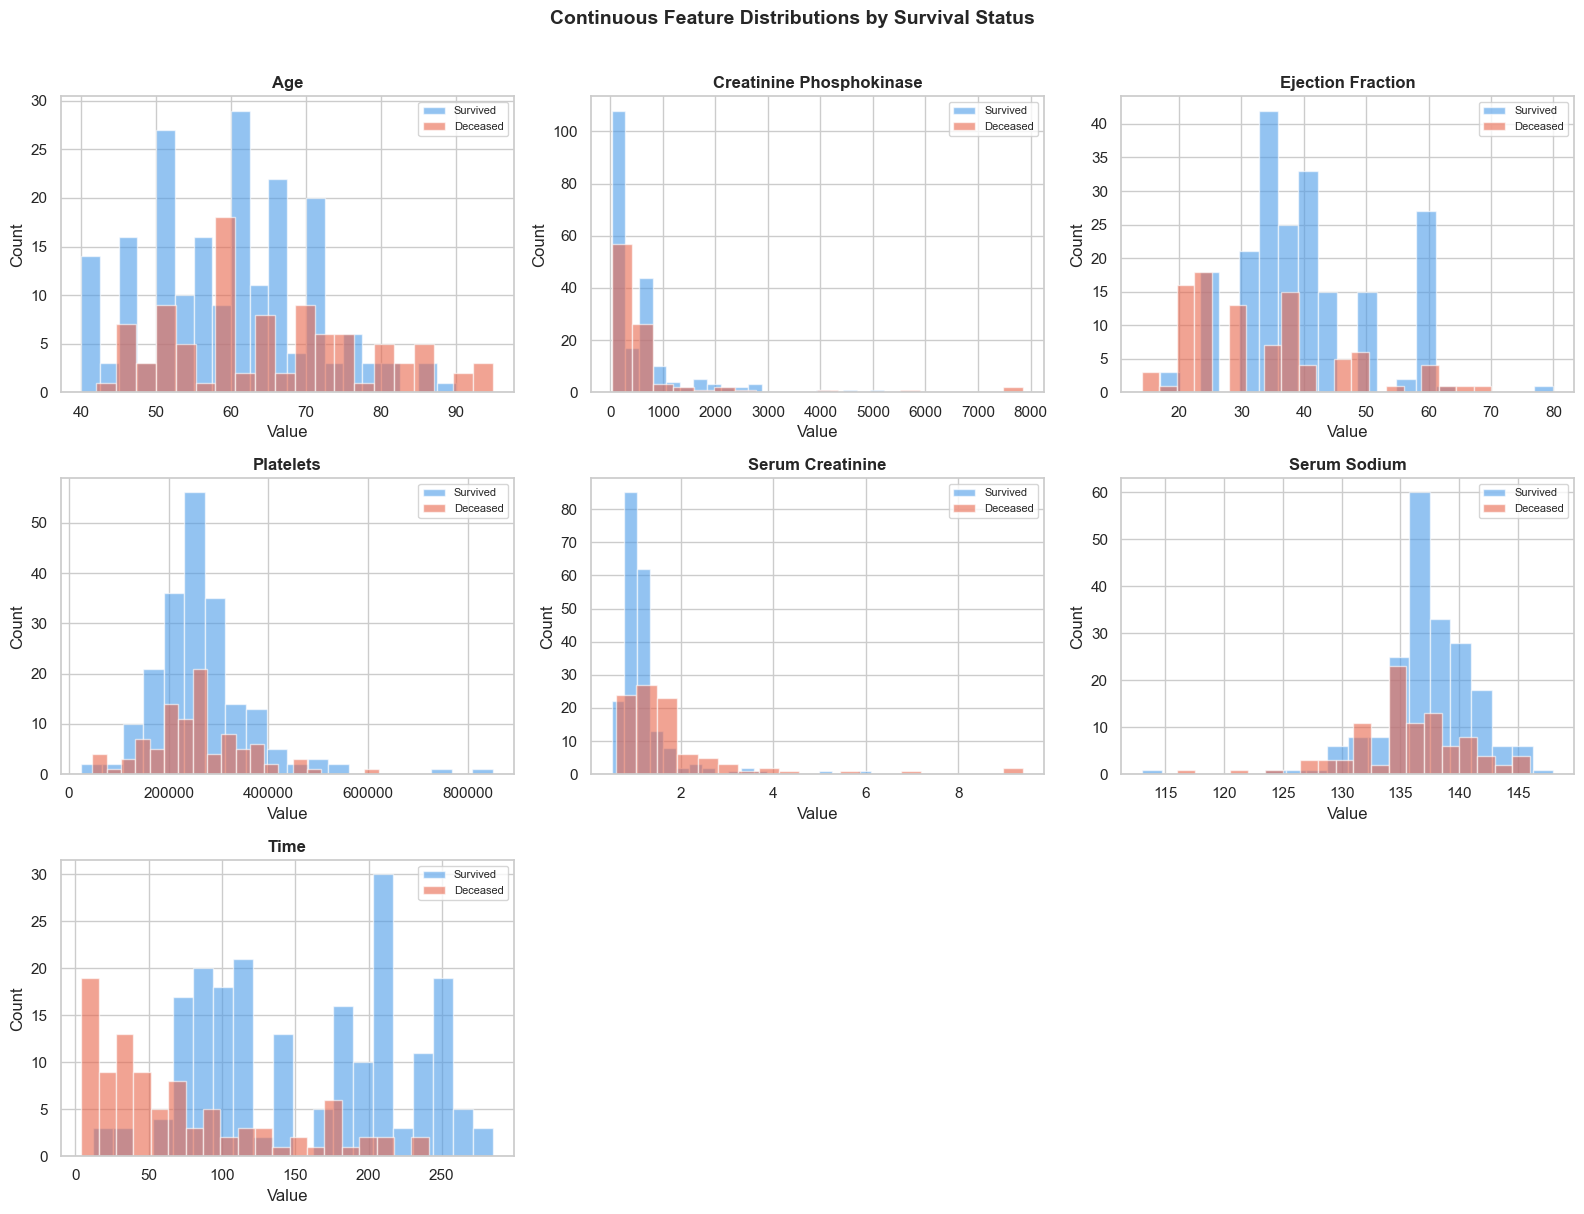

In [22]:
# Feature distributions by outcome (continuous features)
continuous_features = [
    'age', 'creatinine_phosphokinase', 'ejection_fraction',
    'platelets', 'serum_creatinine', 'serum_sodium', 'time'
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, feature in enumerate(continuous_features):
    for outcome, label, color in [(0, 'Survived', '#4C9BE8'), (1, 'Deceased', '#E8664C')]:
        subset = df[df['DEATH_EVENT'] == outcome][feature]
        axes[i].hist(subset, bins=20, alpha=0.6, label=label, color=color, edgecolor='white')
    axes[i].set_title(feature.replace('_', ' ').title(), fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

# Hide unused subplots
for j in range(len(continuous_features), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Continuous Feature Distributions by Survival Status', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

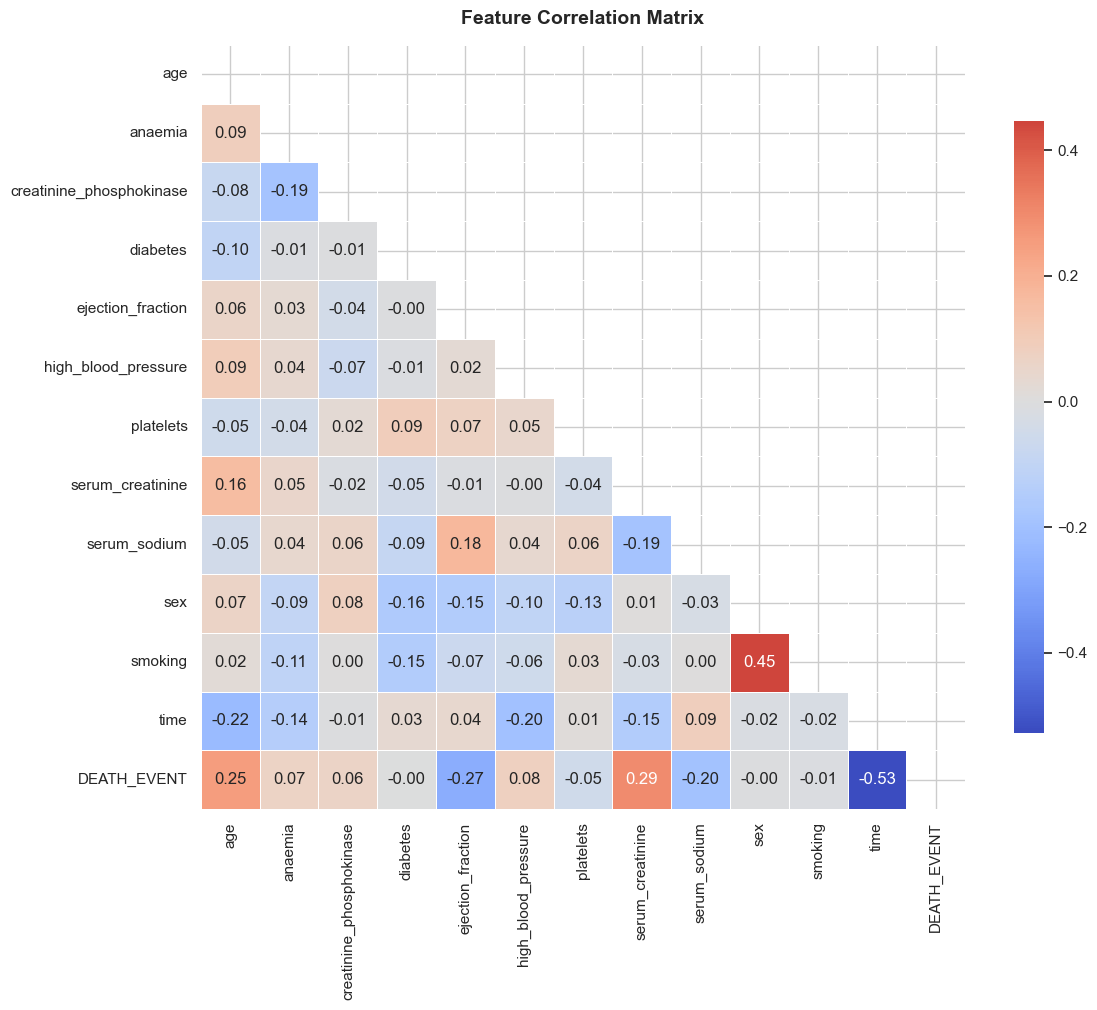

In [23]:
# Correlation heatmap (lower triangle)
fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            ax=ax, square=True, cbar_kws={'shrink': 0.8})

ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

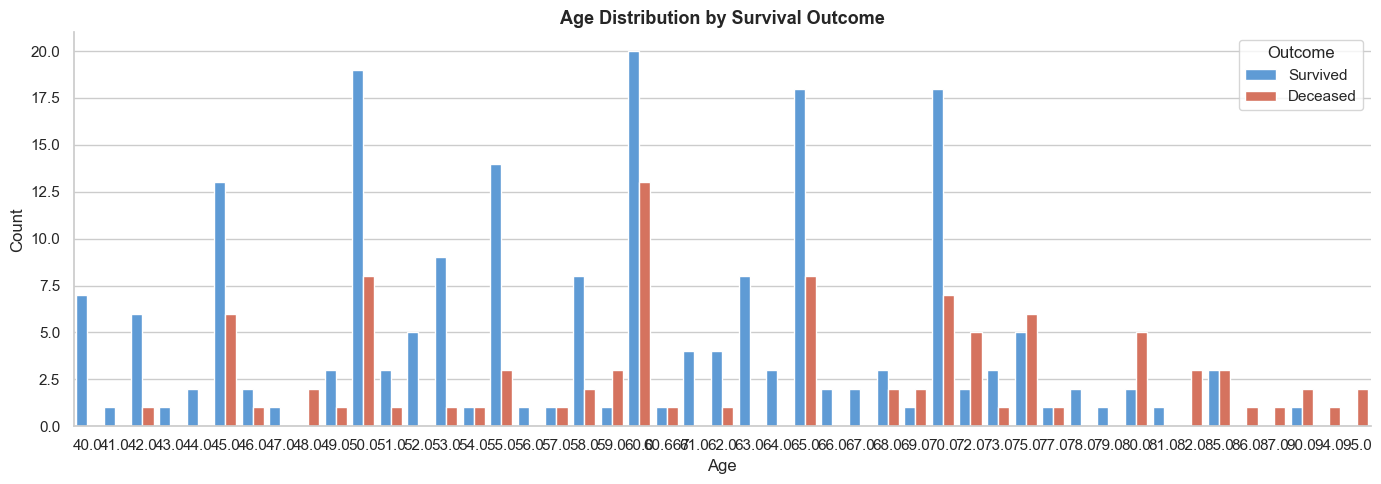

In [24]:
# Age distribution by survival outcome
fig, ax = plt.subplots(figsize=(14, 5))
sns.countplot(x='age', hue='DEATH_EVENT', data=df,
              palette={0: '#4C9BE8', 1: '#E8664C'}, ax=ax)

ax.legend(title='Outcome', labels=['Survived', 'Deceased'])
ax.set_title('Age Distribution by Survival Outcome', fontsize=13, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
sns.despine()
plt.tight_layout()
plt.show()

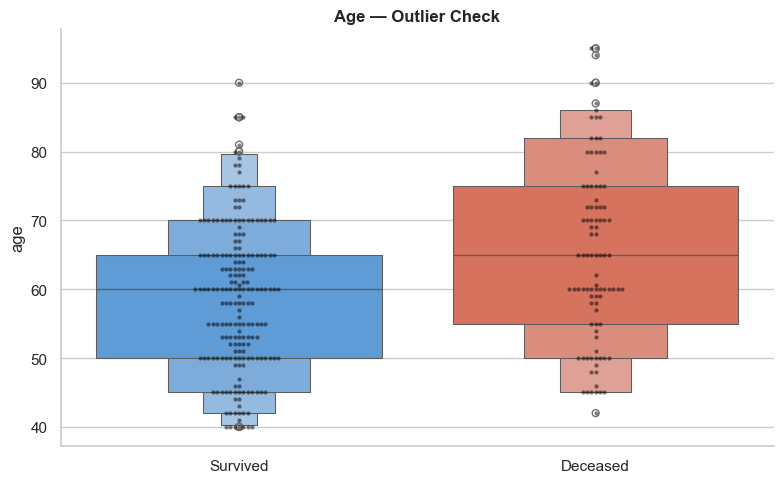

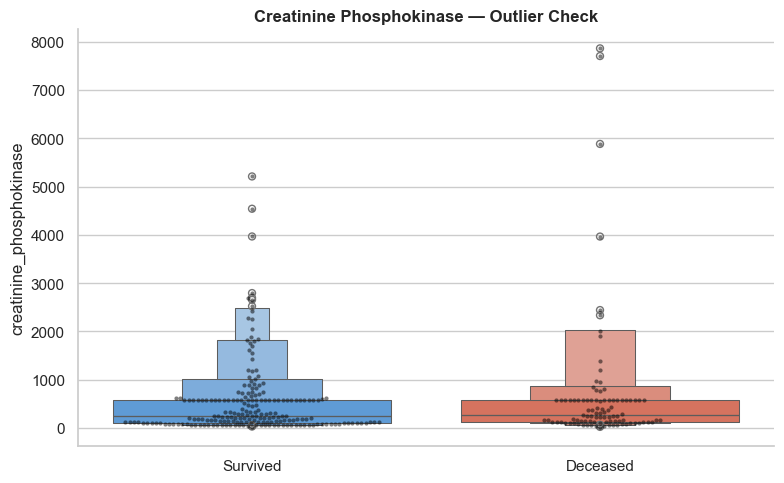

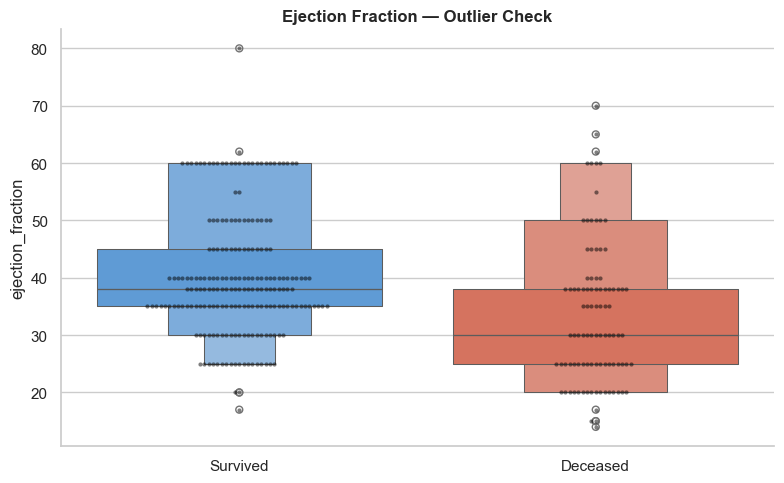

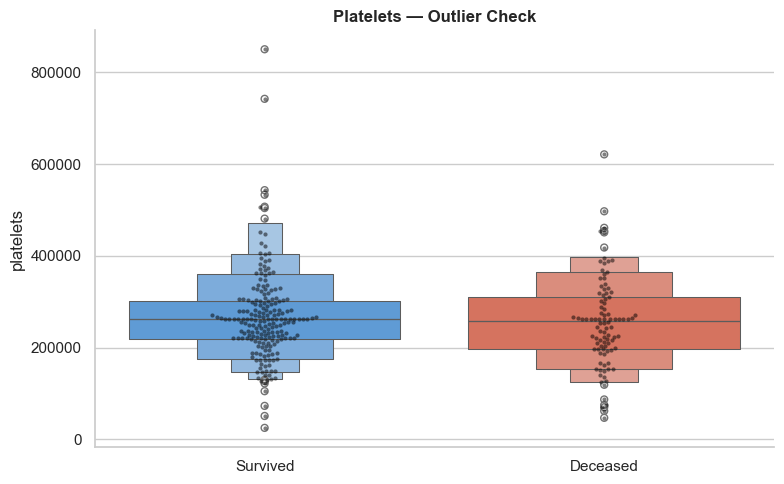

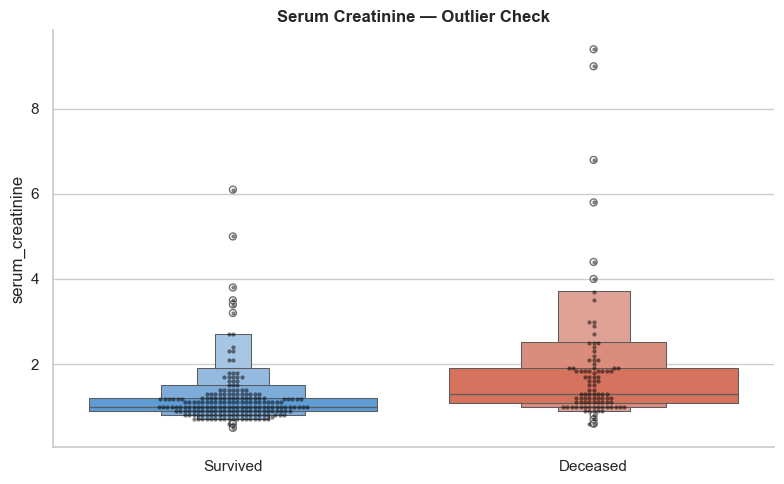

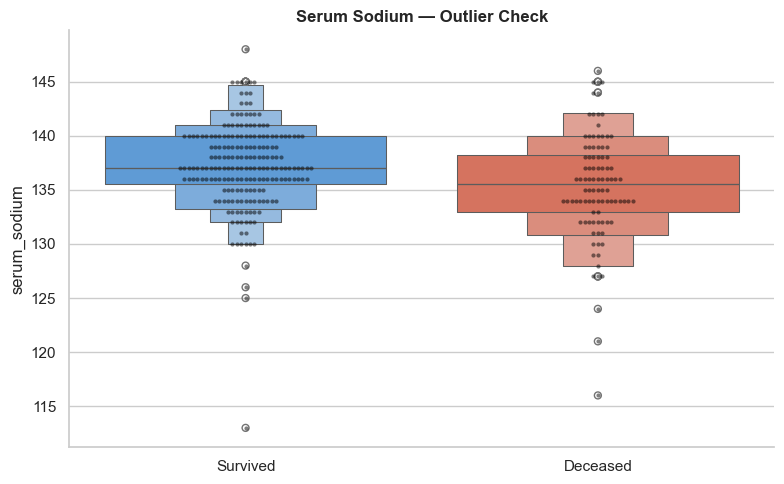

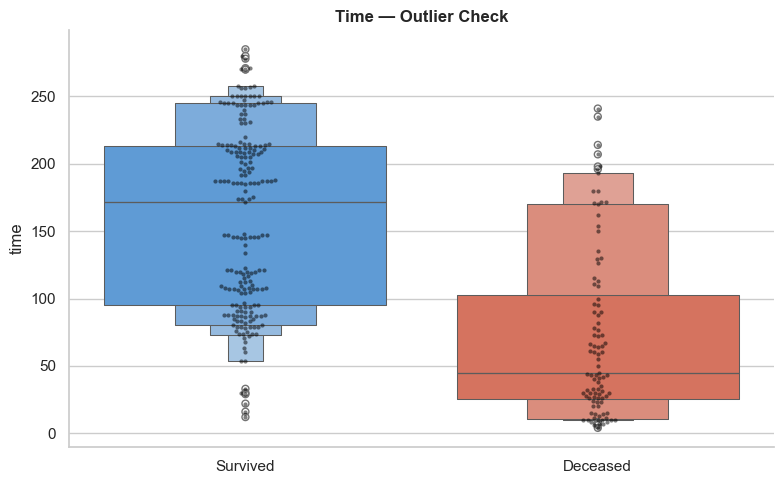

In [26]:
# Boxen + swarm plots for outlier detection
for feature in continuous_features:
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.boxenplot(x=df['DEATH_EVENT'], y=df[feature],
                  palette={'0': '#4C9BE8', '1': '#E8664C'}, ax=ax)
    sns.swarmplot(x=df['DEATH_EVENT'], y=df[feature],
                  color='black', alpha=0.5, size=3, ax=ax)
    ax.set_xticklabels(['Survived', 'Deceased'])
    ax.set_title(f'{feature.replace("_", " ").title()} — Outlier Check', fontweight='bold')
    ax.set_xlabel('')
    sns.despine()
    plt.tight_layout()
    plt.show()

## 4. Data Preprocessing

We separate features from the target, then normalize all feature values using **StandardScaler**. This ensures that no single feature dominates the model due to scale differences — especially important for distance-based models like SVM and KNN.

In [27]:
# Separate features and target
features = df.drop(columns=['DEATH_EVENT'])
target = df['DEATH_EVENT']

print(f'Features shape : {features.shape}')
print(f'Target shape   : {target.shape}')

Features shape : (299, 12)
Target shape   : (299,)


In [28]:
# Standardize features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
features_scaled_df = pd.DataFrame(features_scaled, columns=features.columns)

print('Scaled feature statistics (mean ≈ 0, std ≈ 1):')
features_scaled_df.describe().T[['mean', 'std']].round(4)

Scaled feature statistics (mean ≈ 0, std ≈ 1):


,mean,std
age,0.0,1.0017
anaemia,0.0,1.0017
creatinine_phosphokinase,0.0,1.0017
diabetes,0.0,1.0017
ejection_fraction,-0.0,1.0017
high_blood_pressure,0.0,1.0017
platelets,0.0,1.0017
serum_creatinine,0.0,1.0017
serum_sodium,-0.0,1.0017
sex,-0.0,1.0017


## 5. Train / Test Split

We use a **70% training / 30% test** split. `random_state=25` ensures reproducibility across runs.

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    features_scaled_df, target,
    test_size=0.30,
    random_state=25
)

print('Split Summary:')
print(f'  Total samples : {len(features_scaled_df)}')
print(f'  Training set  : {len(X_train)} samples ({len(X_train)/len(features_scaled_df)*100:.0f}%)')
print(f'  Test set      : {len(X_test)} samples ({len(X_test)/len(features_scaled_df)*100:.0f}%)')

Split Summary:
  Total samples : 299
  Training set  : 209 samples (70%)
  Test set      : 90 samples (30%)


## 6. Model Training & Evaluation

We train three classifiers and evaluate each using Accuracy, Precision, Recall, F1-Score, a confusion matrix heatmap, and a full classification report.

A helper function keeps the evaluation code clean and consistent across all models.

In [30]:
def evaluate_model(model_name: str, y_true, y_pred) -> dict:
    """
    Print metrics and plot a confusion matrix for a given model's predictions.
    Returns a dict of metric scores for later comparison.
    """
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)

    print(f'\n{'=' * 55}')
    print(f'  {model_name}')
    print(f'{'=' * 55}')
    print(f'  Accuracy  : {acc*100:.2f}%')
    print(f'  Precision : {prec*100:.2f}%')
    print(f'  Recall    : {rec*100:.2f}%')
    print(f'  F1-Score  : {f1*100:.2f}%')
    print(f'\nClassification Report:')
    print(classification_report(y_true, y_pred, target_names=['Survived', 'Deceased']))

    # Confusion matrix heatmap
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=0.5,
                xticklabels=['Survived', 'Deceased'],
                yticklabels=['Survived', 'Deceased'],
                cbar=False, ax=ax, annot_kws={'size': 13})
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)
    ax.set_title(f'Confusion Matrix — {model_name}', fontweight='bold', pad=10)
    plt.tight_layout()
    plt.show()

    return {'model': model_name, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}

### 6.1 Support Vector Machine

SVM finds the optimal hyperplane that maximizes the margin between the two classes. We use a **linear kernel** which performs well for linearly separable medical data.


  Support Vector Machine
  Accuracy  : 77.78%
  Precision : 67.86%
  Recall    : 63.33%
  F1-Score  : 65.52%

Classification Report:
              precision    recall  f1-score   support

    Survived       0.82      0.85      0.84        60
    Deceased       0.68      0.63      0.66        30

    accuracy                           0.78        90
   macro avg       0.75      0.74      0.75        90
weighted avg       0.77      0.78      0.78        90



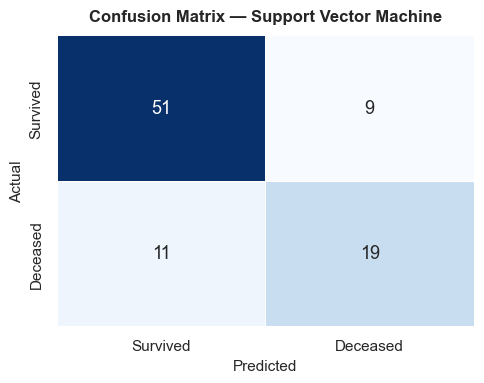

In [31]:
svm_clf = svm.SVC(kernel='linear', random_state=42)
svm_clf.fit(X_train, y_train)
svm_preds = svm_clf.predict(X_test)

svm_results = evaluate_model('Support Vector Machine', y_test, svm_preds)

### 6.2 K-Nearest Neighbors

KNN classifies each sample by majority vote among its **k=5 nearest neighbours** in the feature space. It is intuitive but sensitive to scale — which is why we standardized the features first.


  K-Nearest Neighbors
  Accuracy  : 72.22%
  Precision : 61.90%
  Recall    : 43.33%
  F1-Score  : 50.98%

Classification Report:
              precision    recall  f1-score   support

    Survived       0.75      0.87      0.81        60
    Deceased       0.62      0.43      0.51        30

    accuracy                           0.72        90
   macro avg       0.69      0.65      0.66        90
weighted avg       0.71      0.72      0.71        90



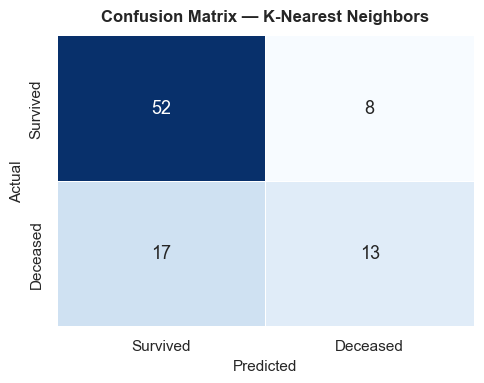

In [32]:
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train, y_train)
knn_preds = knn_clf.predict(X_test)

knn_results = evaluate_model('K-Nearest Neighbors', y_test, knn_preds)

### 6.3 Logistic Regression

Logistic Regression estimates the probability of each class using a logistic function. It is inherently interpretable and performs well on binary classification tasks — making it especially suitable for clinical contexts.


  Logistic Regression
  Accuracy  : 84.44%
  Precision : 76.67%
  Recall    : 76.67%
  F1-Score  : 76.67%

Classification Report:
              precision    recall  f1-score   support

    Survived       0.88      0.88      0.88        60
    Deceased       0.77      0.77      0.77        30

    accuracy                           0.84        90
   macro avg       0.82      0.82      0.82        90
weighted avg       0.84      0.84      0.84        90



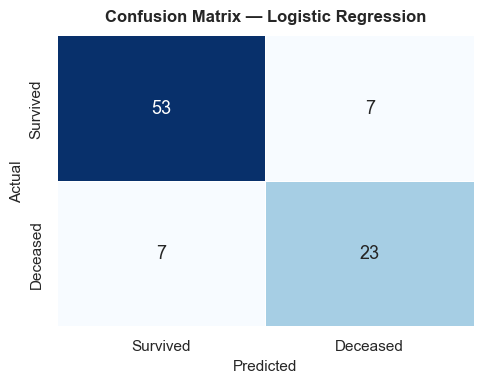

In [33]:
lr_clf = LogisticRegression(random_state=42, max_iter=1000)
lr_clf.fit(X_train, y_train)
lr_preds = lr_clf.predict(X_test)

lr_results = evaluate_model('Logistic Regression', y_test, lr_preds)

## 7. Model Comparison

Now that all three models are evaluated, we compare them side-by-side across all four metrics using a grouped bar chart and a summary table.

In [34]:
# Compile results into a DataFrame
results_df = pd.DataFrame([svm_results, knn_results, lr_results])
results_df = results_df.set_index('model')

print('=== Model Comparison Summary ===')
results_df.style.format('{:.2%}').background_gradient(cmap='RdYlGn', axis=0)

=== Model Comparison Summary ===


,accuracy,precision,recall,f1
model,,,,
Support Vector Machine,77.78%,67.86%,63.33%,65.52%
K-Nearest Neighbors,72.22%,61.90%,43.33%,50.98%
Logistic Regression,84.44%,76.67%,76.67%,76.67%


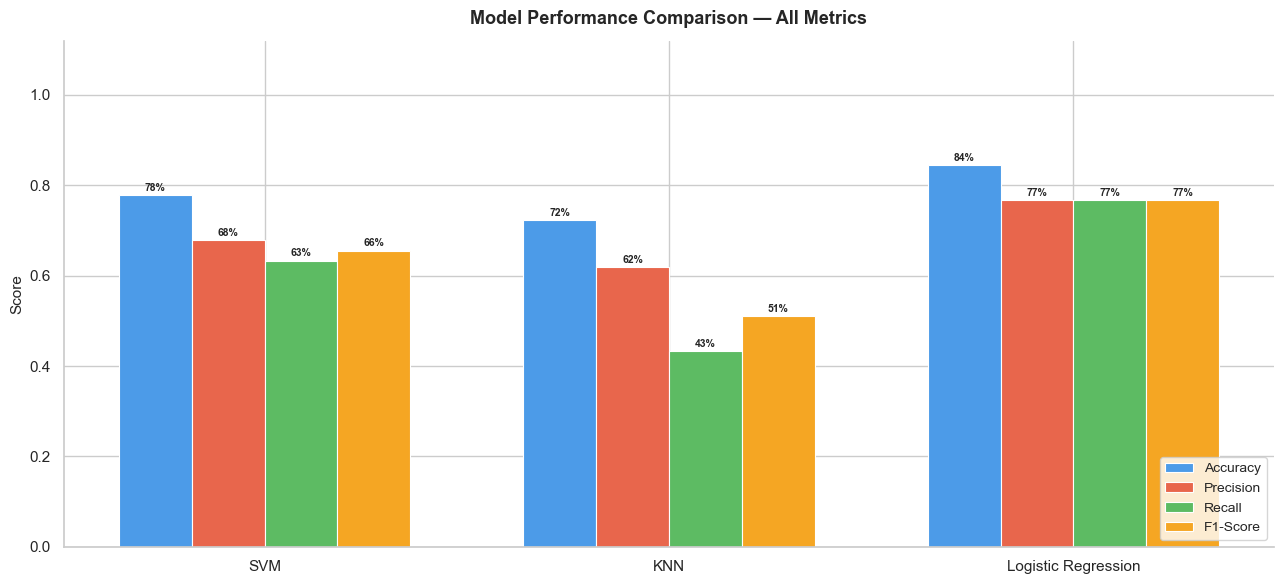


🏆 Best model: Logistic Regression with 84.44% accuracy


In [35]:
# Grouped bar chart comparison
model_labels = ['SVM', 'KNN', 'Logistic Regression']
metrics      = ['accuracy', 'precision', 'recall', 'f1']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors        = ['#4C9BE8', '#E8664C', '#5DBB63', '#F5A623']

x = np.arange(len(model_labels))
bar_width = 0.18

fig, ax = plt.subplots(figsize=(13, 6))

for i, (metric, label, color) in enumerate(zip(metrics, metric_labels, colors)):
    values = results_df[metric].values
    bars = ax.bar(x + i * bar_width, values, width=bar_width,
                  label=label, color=color, edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.0%}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_xticks(x + bar_width * 1.5)
ax.set_xticklabels(model_labels, fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_title('Model Performance Comparison — All Metrics', fontsize=13, fontweight='bold', pad=12)
ax.legend(loc='lower right', fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

best_model = results_df['accuracy'].idxmax()
best_acc   = results_df['accuracy'].max()
print(f'\n🏆 Best model: {best_model} with {best_acc:.2%} accuracy')